✅ โหลดข้อมูลเรียบร้อย! มีทั้งหมด 20 Features

เริ่มเปรียบเทียบ RFE Estimator (เลือก 10 ตัวแปร)...
--------------------------------------------------


>LR: Mean Accuracy 0.665 (Std 0.012)


>CART: Mean Accuracy 0.664 (Std 0.011)


>RF: Mean Accuracy 0.665 (Std 0.009)


>GBM: Mean Accuracy 0.662 (Std 0.009)
--------------------------------------------------


/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14177/479419089.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  pyplot.boxplot(results, labels=names, showmeans=True)


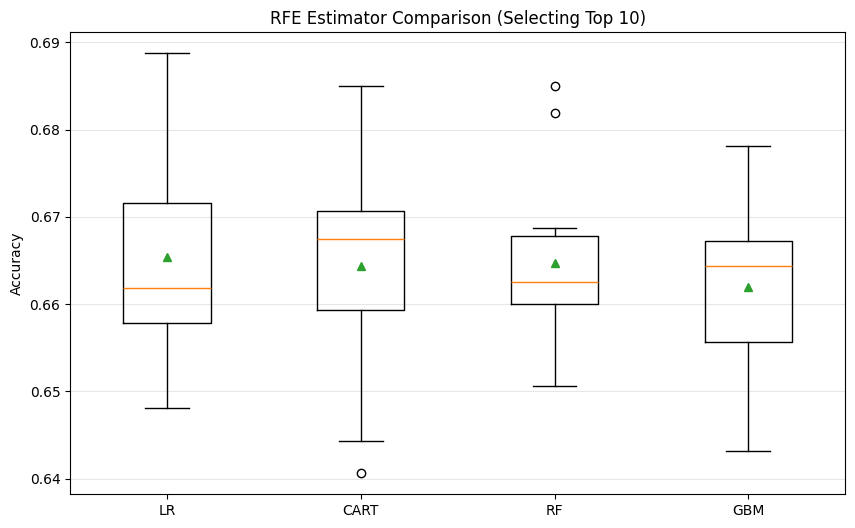

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 📥 1. ส่วนโหลดข้อมูลของตัวเอง (ตามที่ให้มาเลยค่ะ)
# ==========================================
path = '/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/Data_Split/' 

# โหลดข้อมูลเข้า X_train, y_train
X_train = pd.read_csv(f'{path}X_train_80.csv')
y_train = pd.read_csv(f'{path}y_train_80.csv').squeeze() # .squeeze() ดีมากค่ะ แปลงเป็น Series

# เช็คหน่อยว่าข้อมูลมีกี่คอลัมน์ จะได้เลือกจำนวน Feature ถูก
n_features_total = X_train.shape[1]
print(f"✅ โหลดข้อมูลเรียบร้อย! มีทั้งหมด {n_features_total} Features")

# ==========================================
# ⚙️ 2. ตั้งค่าการทดสอบ
# ==========================================
# เราจะคัดให้เหลือแค่กี่ตัวดี? (เช่น 10 ตัว หรือ ครึ่งนึงของที่มี)
n_features_select = 10  # <--- แก้ตัวเลขตรงนี้ได้ค่ะ

# โมเดลที่จะใช้ "ทำนายผล" (Final Estimator)
# ในที่นี้ใช้ Decision Tree ตามตัวอย่างเดิม (หรือจะเปลี่ยนเป็น RandomForest ก็ได้)
final_model = DecisionTreeClassifier(random_state=42)

# ==========================================
# 🛠️ 3. กำหนด RFE Estimator ที่จะส่งเข้าประกวด
# ==========================================
def get_models():
    models = dict()
    
    # 1. LR เป็นคนคัด
    rfe_lr = RFE(estimator=LogisticRegression(solver='liblinear'), n_features_to_select=n_features_select)
    models['LR'] = Pipeline(steps=[('s', rfe_lr), ('m', final_model)])
    
    # 2. Decision Tree เป็นคนคัด
    rfe_cart = RFE(estimator=DecisionTreeClassifier(), n_features_to_select=n_features_select)
    models['CART'] = Pipeline(steps=[('s', rfe_cart), ('m', final_model)])
    
    # 3. Random Forest เป็นคนคัด
    rfe_rf = RFE(estimator=RandomForestClassifier(), n_features_to_select=n_features_select)
    models['RF'] = Pipeline(steps=[('s', rfe_rf), ('m', final_model)])
    
    # 4. Gradient Boosting เป็นคนคัด
    rfe_gbm = RFE(estimator=GradientBoostingClassifier(), n_features_to_select=n_features_select)
    models['GBM'] = Pipeline(steps=[('s', rfe_gbm), ('m', final_model)])
    
    return models

# ==========================================
# 🏁 4. เริ่มการแข่งขัน (Evaluation)
# ==========================================
models = get_models()
results, names = list(), list()

print(f"\nเริ่มเปรียบเทียบ RFE Estimator (เลือก {n_features_select} ตัวแปร)...")
print("-" * 50)

for name, model in models.items():
    # ใช้ Cross Validation 5-Fold
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
    
    # ส่ง X_train, y_train ของเราเข้าไป
    scores = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1)
    
    results.append(scores)
    names.append(name)
    print('>%s: Mean Accuracy %.3f (Std %.3f)' % (name, np.mean(scores), np.std(scores)))

print("-" * 50)

# ==========================================
# 📊 5. พลอตกราฟสรุปผล
# ==========================================
pyplot.figure(figsize=(10, 6))
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.title(f"RFE Estimator Comparison (Selecting Top {n_features_select})")
pyplot.ylabel("Accuracy")
pyplot.grid(axis='y', alpha=0.3)
pyplot.show()



🏆 วิธีที่ดีที่สุดคือ: LR
   Mean Accuracy: 0.665



📋 Top 10 Features Selected by LR:


,Feature,Rank,Selected
0,Age,1,True
17,Fasting Blood Sugar,1,True
15,Sugar Consumption,1,True
14,Sleep Hours,1,True
13,Stress Level,1,True
11,High LDL Cholesterol,1,True
8,BMI,1,True
19,Homocysteine Level,1,True
5,Smoking,1,True
1,Gender,1,True


/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14177/1889871778.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='Rank', y='Feature', palette=colors)


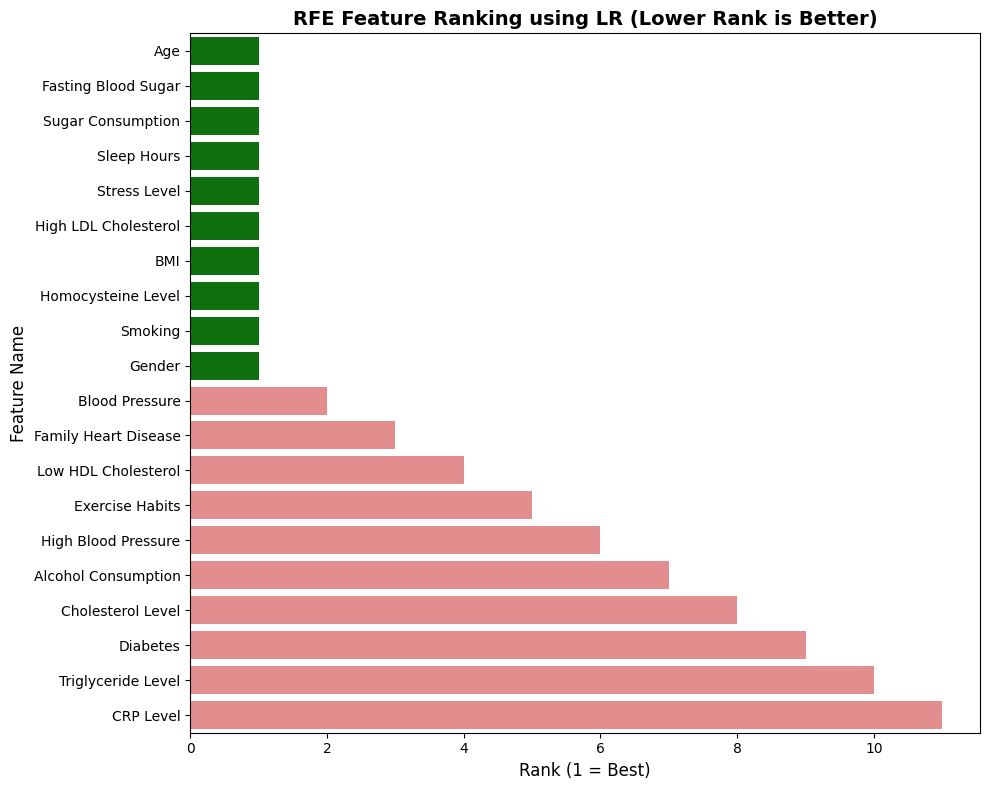


✅ เลือกแล้ว 10 features (สีเขียว)
❌ ไม่เลือก 10 features (สีชมพู)


In [2]:
# ==========================================
# 📊 6. แสดง Feature Rankings จากวิธีที่ดีที่สุด
# ==========================================

# หา Estimator ที่ให้ผลลัพธ์ดีที่สุด
best_idx = np.argmax([np.mean(r) for r in results])
best_name = names[best_idx]
best_model = models[best_name]

print(f"\n🏆 วิธีที่ดีที่สุดคือ: {best_name}")
print(f"   Mean Accuracy: {np.mean(results[best_idx]):.3f}")

# Train โมเดลที่ดีที่สุดเพื่อดู Feature Rankings
best_model.fit(X_train, y_train)

# ดึง RFE object ออกมา (อยู่ใน pipeline step แรก)
rfe = best_model.named_steps['s']

# สร้าง DataFrame เก็บ Feature Rankings
feature_rankings = pd.DataFrame({
    'Feature': X_train.columns,
    'Rank': rfe.ranking_,
    'Selected': rfe.support_
})

# เรียงตาม Rank
feature_rankings = feature_rankings.sort_values('Rank')

print("\n📋 Top 10 Features Selected by", best_name + ":")
display(feature_rankings.head(10))

# พลอตกราฟ Top 20 Features
top_features = feature_rankings.head(20)

plt.figure(figsize=(10, 8))
colors = ['green' if x else 'lightcoral' for x in top_features['Selected']]
sns.barplot(data=top_features, x='Rank', y='Feature', palette=colors)
plt.title(f'RFE Feature Ranking using {best_name} (Lower Rank is Better)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Rank (1 = Best)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n✅ เลือกแล้ว {n_features_select} features (สีเขียว)")
print(f"❌ ไม่เลือก {n_features_total - n_features_select} features (สีชมพู)")

🔵 Features Selected by Logistic Regression:
------------------------------------------------------------
   1. Age
   2. Gender
   3. Smoking
   4. BMI
   5. High LDL Cholesterol
   6. Stress Level
   7. Sleep Hours
   8. Sugar Consumption
   9. Fasting Blood Sugar
  10. Homocysteine Level

🟢 Features Selected by Random Forest:
------------------------------------------------------------
   1. Age
   2. Blood Pressure
   3. Cholesterol Level
   4. BMI
   5. Alcohol Consumption
   6. Sleep Hours
   7. Triglyceride Level
   8. Fasting Blood Sugar
   9. CRP Level
  10. Homocysteine Level

🟡 Features ที่ทั้งคู่เลือก (5 ตัว):
------------------------------------------------------------
  ✓ Age
  ✓ BMI
  ✓ Fasting Blood Sugar
  ✓ Homocysteine Level
  ✓ Sleep Hours

🔵 เฉพาะ LR (5 ตัว): Gender, High LDL Cholesterol, Smoking, Stress Level, Sugar Consumption
🟢 เฉพาะ RF (5 ตัว): Alcohol Consumption, Blood Pressure, CRP Level, Cholesterol Level, Triglyceride Level


/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14177/2001032675.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_top20, x='Rank', y='Feature', palette=colors_lr, ax=axes[0])
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14177/2001032675.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_top20, x='Rank', y='Feature', palette=colors_rf, ax=axes[1])
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14177/2001032675.py:86: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14177/2001032675.py:86: UserWarning: Glyph 128994 (\N{L

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


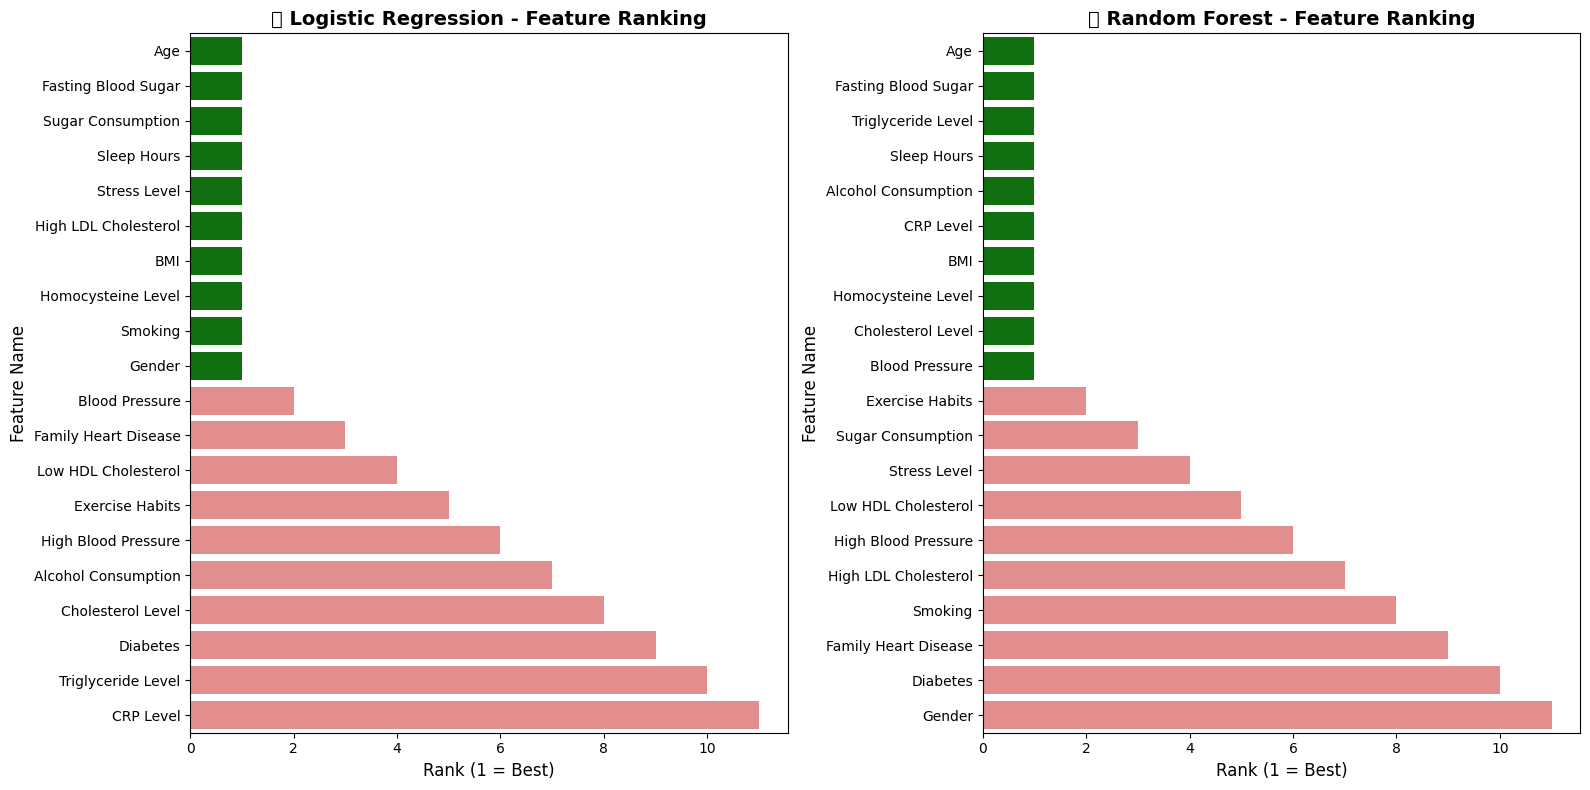


💡 สีเขียว = ถูกเลือก (Top 10) | สีชมพู = ไม่ถูกเลือก

✅ บันทึกไฟล์เรียบร้อย:
   📁 models/rfe_lr_features.pkl
   📁 models/rfe_rf_features.pkl
   📁 models/rfe_common_features.pkl
   📁 models/rfe_best_features.pkl (จาก LR)

🚀 พร้อมไปขั้นตอนถัดไป (Step3) เพื่อเทรนโมเดลได้เลย!


In [3]:
import joblib
import os

# ==========================================
# 📦 บันทึก Features จากทั้ง LR และ RF
# ==========================================

# 1. ดึง Features จาก Logistic Regression
lr_model = models['LR']
lr_model.fit(X_train, y_train)
lr_rfe = lr_model.named_steps['s']
lr_features = X_train.columns[lr_rfe.support_].tolist()

# สร้าง DataFrame สำหรับ LR
lr_rankings = pd.DataFrame({
    'Feature': X_train.columns,
    'Rank': lr_rfe.ranking_,
    'Selected': lr_rfe.support_
}).sort_values('Rank')

# 2. ดึง Features จาก Random Forest
rf_model = models['RF']
rf_model.fit(X_train, y_train)
rf_rfe = rf_model.named_steps['s']
rf_features = X_train.columns[rf_rfe.support_].tolist()

# สร้าง DataFrame สำหรับ RF
rf_rankings = pd.DataFrame({
    'Feature': X_train.columns,
    'Rank': rf_rfe.ranking_,
    'Selected': rf_rfe.support_
}).sort_values('Rank')

# ==========================================
# 📊 เปรียบเทียบ Features ที่เลือก
# ==========================================
print("=" * 60)
print("🔵 Features Selected by Logistic Regression:")
print("-" * 60)
for i, feat in enumerate(lr_features, 1):
    print(f"  {i:2d}. {feat}")

print("\n" + "=" * 60)
print("🟢 Features Selected by Random Forest:")
print("-" * 60)
for i, feat in enumerate(rf_features, 1):
    print(f"  {i:2d}. {feat}")

# หา Features ที่ทั้งสองวิธีเลือกเหมือนกัน
common_features = set(lr_features) & set(rf_features)
lr_only = set(lr_features) - set(rf_features)
rf_only = set(rf_features) - set(lr_features)

print("\n" + "=" * 60)
print(f"🟡 Features ที่ทั้งคู่เลือก ({len(common_features)} ตัว):")
print("-" * 60)
for feat in sorted(common_features):
    print(f"  ✓ {feat}")

if lr_only:
    print(f"\n🔵 เฉพาะ LR ({len(lr_only)} ตัว): {', '.join(sorted(lr_only))}")
if rf_only:
    print(f"🟢 เฉพาะ RF ({len(rf_only)} ตัว): {', '.join(sorted(rf_only))}")

# ==========================================
# 📊 กราฟเปรียบเทียบ LR vs RF
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# กราฟ Logistic Regression
lr_top20 = lr_rankings.head(20)
colors_lr = ['green' if x else 'lightcoral' for x in lr_top20['Selected']]
sns.barplot(data=lr_top20, x='Rank', y='Feature', palette=colors_lr, ax=axes[0])
axes[0].set_title('🔵 Logistic Regression - Feature Ranking', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rank (1 = Best)', fontsize=12)
axes[0].set_ylabel('Feature Name', fontsize=12)

# กราฟ Random Forest
rf_top20 = rf_rankings.head(20)
colors_rf = ['green' if x else 'lightcoral' for x in rf_top20['Selected']]
sns.barplot(data=rf_top20, x='Rank', y='Feature', palette=colors_rf, ax=axes[1])
axes[1].set_title('🟢 Random Forest - Feature Ranking', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rank (1 = Best)', fontsize=12)
axes[1].set_ylabel('Feature Name', fontsize=12)

plt.tight_layout()
plt.show()

print("\n💡 สีเขียว = ถูกเลือก (Top 10) | สีชมพู = ไม่ถูกเลือก")

# ==========================================
# 💾 บันทึกทั้งสองชุด
# ==========================================
os.makedirs('models', exist_ok=True)

joblib.dump(lr_features, 'models/rfe_lr_features.pkl')
joblib.dump(rf_features, 'models/rfe_rf_features.pkl')
joblib.dump(list(common_features), 'models/rfe_common_features.pkl')

# ใช้ชุดของ Best Model (จากผลการประกวดในเซลล์ที่ 1)
best_features = lr_features if best_name == 'LR' else rf_features
joblib.dump(best_features, 'models/rfe_best_features.pkl')

print("\n" + "=" * 60)
print("✅ บันทึกไฟล์เรียบร้อย:")
print("   📁 models/rfe_lr_features.pkl")
print("   📁 models/rfe_rf_features.pkl")
print("   📁 models/rfe_common_features.pkl")
print(f"   📁 models/rfe_best_features.pkl (จาก {best_name})")
print("=" * 60)
print("\n🚀 พร้อมไปขั้นตอนถัดไป (Step3) เพื่อเทรนโมเดลได้เลย!")

/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14177/1065551179.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_top20, x='Rank', y='Feature', palette=colors_rf)
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14177/1065551179.py:13: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


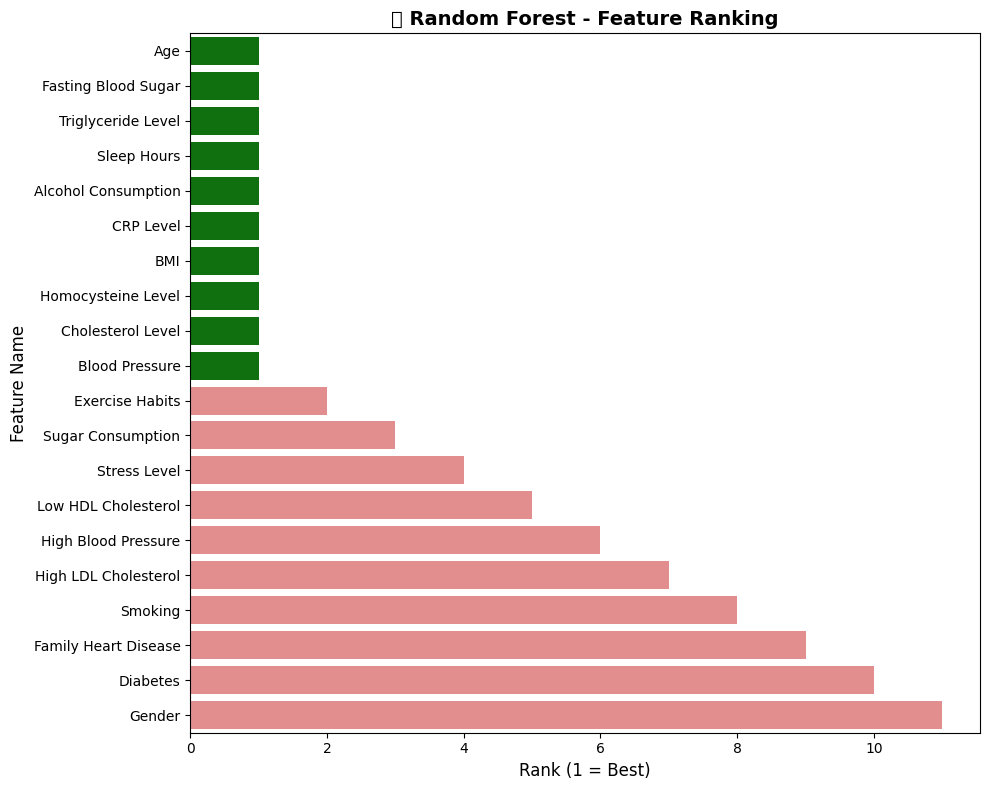

💡 สีเขียว = ถูกเลือก (Top 10) | สีชมพู = ไม่ถูกเลือก


In [4]:
# ==========================================
# 📊 กราฟ Random Forest (แยกเฉพาะ)
# ==========================================
plt.figure(figsize=(10, 8))

rf_top20 = rf_rankings.head(20)
colors_rf = ['green' if x else 'lightcoral' for x in rf_top20['Selected']]

sns.barplot(data=rf_top20, x='Rank', y='Feature', palette=colors_rf)
plt.title('🟢 Random Forest - Feature Ranking', fontsize=14, fontweight='bold')
plt.xlabel('Rank (1 = Best)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

print("💡 สีเขียว = ถูกเลือก (Top 10) | สีชมพู = ไม่ถูกเลือก")